<div class="alert alert-block" style="background-color: #51585eff; border-color: #42474aff; color: white;">
<center> <h1> Syntravel - Travel Diaries Generation </h1> </center> <br>
<center> <h2> EDA </h2></center>

# Table of Contents 

**1. [Importing Libraries and Loading Data](#importing-libraries-and-data)**  
   - [1.1 Importing Libraries](#importing-libraries)  
   - [1.2 Loading and Reading Data](#loading-and-reading-data)  

**2. [Brief Analysis](#brief)**

**3. [Data Cleaning](#datacleaning)**

**4. [Hold-out Cities](#holdout)**

**5. [Base Grouping](#basegrouping)**

**6. [Variables Scoring](#varscoring)**

**7. [Final Subgroups & Persona Objects](#final)**
- [7.1 Scoring Validation](#val)  




# 1. Importing Libraries and Loading Data  <a class="anchor" id="importing-libraries-and-data"></a>

## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [2]:
import os
if not os.path.isdir('llm_config'):
    os.chdir('..')

import random
import json
import pandas as pd
import numpy as np
from pathlib import Path
                                                           
## functions imports
from llm_config.llm_config import *
from Helpers.persona_scoring_validation import *
import Helpers.scoring as scoring
import Helpers.personas_functions as eda_f
import Helpers.visualizations.plotting_functions_eda as plot_f

FIGURES_DIR = Path('figures/01_personas')

## 1.2. Loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>

In [3]:
odin = pd.read_csv(r'ODiN (DATA)\DATAVERSE\ODiN Data (RAW)\ODiN_ENG.csv', sep=',')
#odin.head()

In [4]:
odin_dec = pd.read_csv(r'ODiN (DATA)\DATAVERSE\ODiN Data (RAW)\ODiN_ENG_decoded.csv', sep=',')
#odin_dec.head(3)

C:\Users\X1605\AppData\Local\Temp\ipykernel_47108\4231969443.py:1: DtypeWarning: Columns (0: Number of people in household, 1: Number of household members aged 6 to 11, 2: Number of household members aged 18 or older, 3: Age OP, 4: Number of passenger cars registered in OP's name, 5: Number of motorcycles in household, 6: Number of engines in OP name, 7: Number of mopeds in household, 8: Number of mopeds in OP's name, 9: Number of mopeds in household name, 10: Number of mopeds in the name OP, 11: Travel distance in the Netherlands (in hectometers), 12: Travel time in the Netherlands (in minutes), 13: End of hour series, 14: Final minute series, 15: Trip distance in the Netherlands (in hectometers), 16: Trip duration in the Netherlands (in minutes)) have mixed types. Specify dtype option on import or set low_memory=False.
  odin_dec = pd.read_csv(r'ODiN (DATA)\DATAVERSE\ODiN Data (RAW)\ODiN_ENG_decoded.csv', sep=',')


In [5]:
# Stripping whitespace from string columns in the DataFrame
odin_dec = odin_dec.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
odin_dec.to_csv('ODiN (DATA)/DATAVERSE/ODiN Data (RAW)/ODiN_ENG_decoded.csv', index=False, encoding='utf-8-sig')
print('Done')

Done


## 2. Brief Analysis <a class="anchor" id="brief"></a>

In [6]:
odin.info()

<class 'pandas.DataFrame'>
RangeIndex: 200054 entries, 0 to 200053
Columns: 250 entries, Unnamed: 0 to Person_index
dtypes: float64(9), int64(162), str(79)
memory usage: 381.6 MB


In [7]:
odin_dec.info()

<class 'pandas.DataFrame'>
RangeIndex: 200054 entries, 0 to 200053
Columns: 249 entries, New person to Person_index
dtypes: float64(26), int64(14), str(209)
memory usage: 380.0 MB


In [8]:
# For now on we procced with the decoded version of the data

print(odin_dec['Person_index'].nunique()) # This is the real individual correspondent to individual peron id (matches the ppw)
print(odin_dec['Trip_ID'].nunique()) # makes sense, cause each row is a trip 
print(odin_dec['Unique ID for each OP'].nunique()) # household level



61953
200054
9908


In [9]:
dupes = odin_dec.columns[odin_dec.columns.duplicated()].tolist()
print(f"Duplicate columns: {dupes}")

# no duplicates


Duplicate columns: []


In [10]:
# NAn values analysis
nan_counts = odin_dec.isna().sum()
nan_pct = (nan_counts / len(odin_dec)) * 100

null_cols = nan_pct[nan_pct > 40].index.tolist()
for col in null_cols:
    print(f"{col}: {nan_counts[col]} occurrences ({nan_pct[col]:.2f}%)")

Number of people in household: 122880 occurrences (61.42%)
Number of household members aged 6 to 11: 195958 occurrences (97.95%)
Age OP: 167286 occurrences (83.62%)
Number of passenger cars registered in OP's name: 191862 occurrences (95.91%)
Number of motorcycles in household: 183670 occurrences (91.81%)
Number of engines in OP name: 191862 occurrences (95.91%)
Number of mopeds in household: 179574 occurrences (89.76%)
Number of mopeds in OP's name: 187766 occurrences (93.86%)
Number of mopeds in household name: 191862 occurrences (95.91%)
Number of mopeds in the name OP: 195958 occurrences (97.95%)
Number of addresses visited serial movement: 199215 occurrences (99.58%)
All addresses in the same place: 199215 occurrences (99.58%)
Place name 1: 199215 occurrences (99.58%)
Place name 2: 199215 occurrences (99.58%)
Place name 3: 199215 occurrences (99.58%)
Place name 4: 199215 occurrences (99.58%)
Place name 5: 199215 occurrences (99.58%)
Distance of serial movement in the Netherlands (

In [11]:
# data type issues analysis
dtype_issues = {}
for col in odin_dec.columns:
    series = odin_dec[col].dropna()
    if series.empty:
        continue
    inferred = pd.api.types.infer_dtype(series, skipna=True)
    actual = odin_dec[col].dtype
    # Flag object columns that are actually numeric
    if actual == object:
        converted = pd.to_numeric(series, errors="coerce")
        numeric_ratio = converted.notna().sum() / len(series)
        if numeric_ratio > 0.8:
            dtype_issues[col] = f"stored as object, {numeric_ratio:.0%} numeric values"
    # Flag numeric columns that contain only integers stored as float
    elif pd.api.types.is_float_dtype(actual):
        if series.dropna().apply(lambda x: x == int(x)).all():
            dtype_issues[col] = f"float but all values are whole numbers → should be int"
    # Flag columns with mixed types
    if inferred in ("mixed", "mixed-integer", "mixed-integer-float"):
        dtype_issues[col] = f"mixed types detected (inferred: {inferred})"

print(f"=== Dtype issues found: {len(dtype_issues)} ===")
for col, reason in dtype_issues.items():
    print(f"  {col}: {reason}")

=== Dtype issues found: 26 ===
  Unique ID for each OP: float but all values are whole numbers → should be int
  Unique ID for every move: float but all values are whole numbers → should be int
  Movement number: float but all values are whole numbers → should be int
  Number of journeys displacement: float but all values are whole numbers → should be int
  Postal code of departure point: float but all values are whole numbers → should be int
  Postal code of departure point abroad: float but all values are whole numbers → should be int
  Arrival point postal code: float but all values are whole numbers → should be int
  Postal code of arrival point abroad: float but all values are whole numbers → should be int
  Dutch postcode border crossing: float but all values are whole numbers → should be int
  Foreign postcode border crossing: float but all values are whole numbers → should be int
  Departure time transfer: float but all values are whole numbers → should be int
  Departure minut

In [12]:
## The datypes will be left as floats since the varibales have nan values. 

## 3. Data Cleaning <a class="anchor" id="datacleaning"></a>

### Filtering to get the independent and regular trips (no atypical days and holidays)

In [13]:
print(odin_dec['New move'].value_counts().sort_index())

## For the sake of simplicity, and following the inspired frameworks, the df will be filtered with only new moves, meaning independent ones.

New move
New move                                   172256
No new move                                 15670
Professional serial movement with truck       117
Professional truck movement                   109
Serial displacement                           722
Name: count, dtype: int64


In [14]:
# Saving stats for stage 2, so we can introduce zero trip personas in the syntehtic travelers generation.
non_travelers = odin_dec[odin_dec['Reason not to go'] != 'Does not apply']

zero_trip_stats = {
    "zero_trip_rate": len(non_travelers) / len(odin_dec),
    "reason_distribution": non_travelers['Reason not to go']
                           .value_counts(normalize=True).to_dict()}

atypical_rate = (odin_dec['Details on reporting day'] == 'Yes').mean()
print(f"Atypicality rate: {atypical_rate:.1%}")  # for Stage 2 injection

Atypicality rate: 26.7%


In [15]:
# Applying filters 
odin_df = odin_dec[
    (odin_dec['New move'] == 'New move') &
    (odin_dec['Details on reporting day'].isin(['No, no specifics', 
                                                'No, this weekday is always different'])) &
    (odin_dec['Reporting day is a holiday'] == 'No')
].copy()

print(f"Original : {len(odin_dec):,} rows")
print(f"Filtered : {len(odin_df):,} rows")
print(f"Lost     : {len(odin_dec) - len(odin_df):,} rows ({(1 - len(odin_df)/len(odin_dec))*100:.1f}%)")

Original : 200,054 rows
Filtered : 122,341 rows
Lost     : 77,713 rows (38.8%)


In [16]:
# Confirming if it's balanced between the day's 
print(odin_df['Weekday reporting'].value_counts(normalize=True))
print(odin_df['Details on reporting day'].value_counts())

Weekday reporting
Saturday     0.153415
Friday       0.152050
Tuesday      0.149786
Wednesday    0.145904
Monday       0.143264
Thursday     0.141825
Sunday       0.113756
Name: proportion, dtype: float64
Details on reporting day
No, no specifics                        79420
No, this weekday is always different    42921
Name: count, dtype: int64


In [17]:
odin_df['DayType'] = odin_df['Weekday reporting'].isin(['Saturday', 'Sunday']).map({True: 'weekend', False: 'weekday'})
print(odin_df['DayType'].value_counts(normalize=True))
print(odin_df['DayType'].unique())

DayType
weekday    0.732829
weekend    0.267171
Name: proportion, dtype: float64
<StringArray>
['weekday', 'weekend']
Length: 2, dtype: str


In [18]:

print(f" lost respondents : {odin_dec['Person_index'].nunique() - odin_df['Person_index'].nunique()}")
print(f" retained respondents : {odin_df['Person_index'].nunique()}")
print(f" original respondents : {odin_dec['Person_index'].nunique()}")

 lost respondents : 24537
 retained respondents : 37416
 original respondents : 61953


In [19]:
print(odin_df.shape)

(122341, 250)


### Reducing the columns

In [20]:
odin_cleaned = odin_df.copy()

#### Income, age, Occupation (Activity Status)

#### Income


In [21]:
def income_level(row):
    low_ink = str(row['Deviation from low-income limit'])
    soc_ink = str(row['Deviation from social minimum'])
    decile  = row['Standardized household disposable income (10% groups)']
    if 'up to 101%' in soc_ink or 'up to 100%' in soc_ink:
        return 'Below subsistence'
    if any(x in low_ink for x in ['up to 80%', 'up to 90%', 'up to 100%']):
        return 'Low income'
    decile_map = {
        'First 10% group':   'Low income',
        'Second 10% group':  'Low income',
        'Third 10% group':   'Below median',
        'Fourth 10% group':  'Below median',
        'Fifth 10% group':   'Below median',
        'Sixth 10% group':   'Median',
        'Seventh 10% group': 'Median',
        'Eighth 10% group':  'Above median',
        'Ninth 10% group':   'Above median',
        'Tenth 10% group':   'High income',
    }
    return decile_map.get(decile, 'Unknown')

In [22]:
odin_cleaned['income_level'] = odin_cleaned.apply(income_level, axis=1)
odin_cleaned['income_level'].value_counts(normalize=True).mul(100).round(1).sort_values()

income_level
Unknown               2.0
Below subsistence     2.5
Low income            8.4
High income          14.2
Median               21.5
Below median         25.3
Above median         26.2
Name: proportion, dtype: float64

In [23]:
### choosing income variable 
### Keeping Standardized household disposable income because it it normalises all incomes to a single-person equivalent,representing the purchasing power per person
odin_cleaned = odin_cleaned.drop(columns=[                         
      'Household disposable income (10% groups)',        
      'Deviation from low-income limit',                   
      'Deviation from social minimum',
      'Household prosperity (10% groups)',
      
  ])  

#### Age


In [24]:
# Age associated variables 
## Colapsing the information in one, keeping also the number of household members under 18, let the llm choose
odin_cleaned['household_with_minor'] = odin_cleaned.apply(eda_f.minor_category, axis=1)

## droping irrelevant ones 
age_vars_to_drop = [
    'Age OP',
    'Number of household members aged 18 or older'
    ]
odin_cleaned = odin_cleaned.drop(columns=age_vars_to_drop, errors='ignore')

In [25]:
# This was inspired by the classes used in previous works
age_remap = {                                                                                     
      '15 to 17 years':      '<18',                                
      '18 to 19 years old':  '18-25',                              
      '20 to 24 years':      '18-25',
      '25 to 29 years':      '26-30',                              
      '30 to 34 years':      '31-35',
      '35 to 39 years':      '36-40',
      '40 to 44 years':      '41-45',
      '45 to 49 years':      '46-50',
      '50 to 54 years':      '51-66',
      '55 to 59 years':      '51-66',
      '60 to 64 years':      '51-66',
      '65 to 69 years':      '65+',
      '70 to 74 years':      '65+',
      '75 to 79 years':      '65+',
      '80 years or older':   '65+',
      '6 to 11 years':       '<18',
      '12 to 14 years':      '<18',
      '18 to 34 years':      '18-25',
      '35 to 54 years':      '36-40',
      '55 to 74 years':      '51-66',
      '75+ years':           '65+',
  }

## Colapsing Age into the bins of Mobagent
odin_cleaned['Age class OP'] = odin_cleaned['Age class OP'].replace(age_remap)

# Verify
print(odin_cleaned['Age class OP'].value_counts(normalize=True).mul(100).round(1).sort_values())


Age class OP
36-40     6.2
26-30     6.3
41-45     6.7
46-50     6.8
31-35     6.9
18-25     8.2
<18      12.8
51-66    22.8
65+      23.2
Name: proportion, dtype: float64


#### Activity 

In [26]:
## Colapsing the occupation variables 
odin_cleaned['Activity_status'] = odin_cleaned.apply(eda_f.activity_status, axis=1)

In [27]:
# Nan  values were being assigned to 'inactive' category, but they are actually not asked, so we will assign them to NaN to avoid confusion.
# More Nan value were minors not assigned to a catgepry so they will be reassigned to pupil category which is the standard Dutch/EU education term
odin_cleaned.loc[odin_cleaned['Paid work OP'] == 'Not asked', 'Activity_status'] = None

odin_cleaned['Activity_status'] = odin_cleaned.apply(lambda row: 'student' if pd.isna(row['Activity_status']) and row['Age class OP'] == '<18'
    else row['Activity_status'],
    axis=1
  )

print(odin_cleaned['Activity_status'].value_counts(dropna=False))

Activity_status
employed           64992
retired            24900
student            19795
inactive            3949
homemaker           3497
incapacitated       3033
unemployed          1207
working_retired      968
Name: count, dtype: int64


In [28]:
# Remooving orginal occupation var 
odin_cleaned = odin_cleaned.drop(columns=[
      'Paid work OP',
      'Unpaid activity OP',
      'Social participation OP',
      'OP has a Student OV chip card',
  ], errors='ignore')

### Not usefull features

In [29]:
# We care about whether someone has or not a car, not about fuel and  year of the car and more car registry details. Droping all of that variables 

vehicle_vars = [
    # Youngest car
    'First fuel for youngest passenger car in household name',
    'Second fuel, youngest passenger car in household name',
    'Year of manufacture of youngest passenger car in household name',
    'Year of construction class of youngest passenger car in household name',
    'Weight class of youngest passenger car in household name',
    #  Second youngest car
    'First fuel second youngest passenger car in household name',
    'Second fuel second youngest passenger car in household name',
    'Year of construction second to youngest passenger car in household name',
    'Year of construction class second youngest passenger car in household name',
    'Weight class second youngest passenger car in household name',
    # Lease/company car 
    'First fuel lease car or passenger car in company name in household',
    'Second fuel lease car or passenger car in the name of a company in the household',
    'Year of construction of lease car or passenger car in the name of company in household',
    'Year of construction class lease car or passenger car in the name of company in household',
    'Weight class lease car or passenger car in the name of company in household',

    # Eltric car details 
    'Type of electric car, youngest passenger car in household name',
    'Type of electric car second youngest passenger car in household name',
    'Type of electric car, lease car or passenger car in the name of company in household',
    'Registration of youngest passenger car in household name',
    'Registration of the second youngest passenger car in the name of the household',
]


odin_cleaned = odin_cleaned.drop(columns=vehicle_vars, errors='ignore')

In [30]:
# This variables tend to influence mode choice but the signal is already capture in car owrnwership, urbanization level and freq ones
reimbursement_vars = [
    'Receives reimbursement from employer for travel to work',
    'Travel allowance is a fixed amount per period',
    'Reimbursement per actual kilometer driven',
    'Reimbursement of fuel costs',
    'Reimbursement of public transport subscription or public transport trips',
    'Reimbursement of purchase costs of means of transport',
    'Leased vehicle or employer\'s company vehicle',
    'Reimbursement is a mobility budget',
    'Parking costs',
    'Storage costs',
]
odin_cleaned = odin_cleaned.drop(columns=reimbursement_vars, errors='ignore')

In [31]:
# We capture what matters with  Province of residential municipality, Departure town and Arrival municipality
mra_vars = [
    # Residence
    'Amsterdam Metropolitan Region',
    'Metropolitan Region Rotterdam The Hague',
    'Province of Utrecht',
    # Trip origin
    'Amsterdam Metropolitan Region starting point',
    'Metropolitan Region Rotterdam The Hague starting point',
    'Province of Utrecht starting point',
    # Trip destination
    'Amsterdam Metropolitan Region arrival point',
    'Metropolitan Region Rotterdam The Hague arrival point',
    'Province of Utrecht arrival point',
]
odin_cleaned = odin_cleaned.drop(columns=mra_vars, errors='ignore')

In [32]:
# we filtered to only have independent trips, so these variables are not relevant anymore

serial_vars = [
    'Number of addresses visited serial movement',
    'All addresses in the same place',
    'Place name 1',
    'Place name 2',
    'Place name 3',
    'Place name 4',
    'Place name 5',
    'Distance of serial movement in the Netherlands (in hectometers)',
    'Distance serial movement abroad (in hectometers)',
    'First means of transport for serial movements',
    'Second means of transport serial movement',
    'Third means of transport serial movement',
    'Fourth means of transport serial movement',
    'Series start time',
    'Start minute series',
    'End of hour series',
    'Final minute series',
    'Number of serial movements without professional use with OP truck in the Netherlands',
    'Total distance traveled serial trips OP in the Netherlands (in hectometers)',
]
odin_cleaned = odin_cleaned.drop(columns=serial_vars, errors='ignore')

In [33]:
# already used 
odin_cleaned = odin_cleaned.drop(columns=['Reporting day is a holiday'], errors='ignore')

In [34]:
## Variables with more than 50% of missing vlaues

moped_vars = [
      'Number of motorcycles in household',
      'Number of engines in OP name',
      'Number of mopeds in household',
      'Number of mopeds in OP\'s name',
      'Number of mopeds in household name',
      'Number of mopeds in the name OP',
      'Number of passenger cars registered in OP\'s name',
  ]

odin_cleaned = odin_cleaned.drop(columns=moped_vars, errors='ignore')

In [35]:
drop_vars = {
    # Survey admin / technical flags
    'admin_vars': [
        'New person', 'Sampling indicator', 'Response mode',
        'Reporting year',                       # all 2022, zero variance
        'Reporting week',                       # redundant with month
        'New move',                             # used as filter already
        'Movement number',                      # internal sequencing
        'New ride',                             # internal sequencing
        'Correction of movements to journeys',
        'Removed all foreign relocation',
        'Correction due to speed',
        'Airplane ride removed',
        'Household weighting factor', 'Person weighting factor', 'Displacement weighting factor',
        'AutoHhL',                              # internal household lease code
        'Neighborhood combination Amsterdam',   # oversample flag
    ],

    # Fuel columns that slipped through (leading spaces)
    'slipped_vars': [
        ' First fuel for youngest passenger car in household name',
        ' Second fuel, youngest passenger car in household name',
        ' First fuel second youngest passenger car in household name',
        ' Second fuel second youngest passenger car in household name',
    ],


}

# Drop all grouped vars
for group, cols in drop_vars.items():
    odin_cleaned = odin_cleaned.drop(columns=cols, errors='ignore')

# Drop all Reason A/B accessibility variables (conditional on "cannot reach", mostly "Does not apply")
reason_vars = [c for c in odin_cleaned.columns if c.startswith('Reason')]

odin_cleaned = odin_cleaned.drop(columns=reason_vars, errors='ignore')

In [36]:
# Filtered before
zero_trip_vars = ["Didn't go away: expensive illness", "Didn't go away: type of weather",
                  "Didn't leave: reason for staying abroad", 'OP has been away in the Netherlands']

odin_cleaned = odin_cleaned.drop(columns=zero_trip_vars, errors='ignore')

In [37]:
abroad_vars = ['Postal code of departure point abroad', 'Postal code of arrival point abroad',
               'Trip distance abroad (in hectometers)', 'Journey time abroad (in minutes)',
               'Foreign postcode border crossing']

# 99% trips are domestic 
odin_cleaned = odin_cleaned.drop(columns=abroad_vars, errors='ignore')     

In [38]:
byz_vars = [' Special feature: other addresses', 'Special feature: other means of transport',
            'Special feature: different times', 'Special feature: different travel duration',
            'Special feature: different route', 'Details on reporting day']

## all not asked 
odin_cleaned = odin_cleaned.drop(columns=byz_vars,errors='ignore')

In [39]:
geo_to_drop = ['Departure area', 'Arrivals area','Dutch postcode border crossing', 'Dutch municipal border crossing',
                    ]
odin_cleaned = odin_cleaned.drop(columns=geo_to_drop, errors='ignore')

In [40]:
print(f"Lost columns : {odin_dec.shape[1] - odin_cleaned.shape[1]}")

Lost columns : 127


## 4. Hold-out Cities <a class="anchor" id="holdout"></a>

- Utrecht was chosen because it's a very urban province with a reasonable ammount of respondents but not so many it hurts the trainning

- Friesland was chosen because it's more rural 

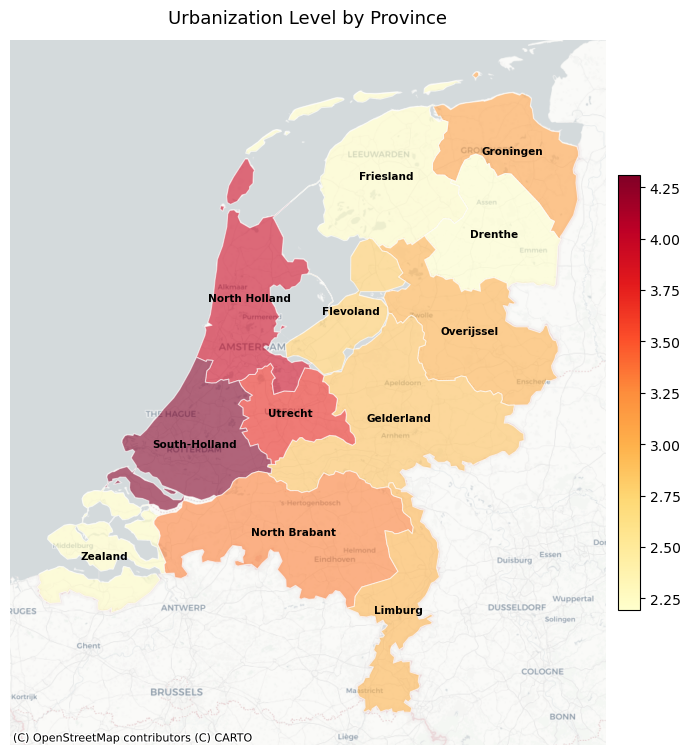

In [41]:
plot_f.plot_province_urbanization(odin_cleaned, save_path=FIGURES_DIR / 'province_urbanization.png')

In [42]:
HOLDOUT_PROVINCES = ['Utrecht', 'Friesland'] # 1st has the majoriry of trips comming from urban areas, second its opposite
province_col = 'Province of residential municipality'

In [43]:
odin_cleaned['Province of residential municipality'].unique().tolist()

['Drenthe',
 'South-Holland',
 'North Brabant',
 'Gelderland',
 'North Holland',
 'Utrecht',
 'Flevoland',
 'Overijssel',
 'Groningen',
 'Limburg',
 'Friesland',
 'Zealand']

In [44]:
 # Split train / holdout
odin_holdout = odin_cleaned[odin_cleaned[province_col].isin(HOLDOUT_PROVINCES)].copy()
odin_train   = odin_cleaned[~odin_cleaned[province_col].isin(HOLDOUT_PROVINCES)].copy()

In [45]:
odin_holdout.to_csv('ODiN (DATA)/DATAVERSE/intermediarie_csvs/odin_holdout.csv', index=False)
print(f'Train: {odin_train.shape}, Holdout: {odin_holdout.shape}')

Train: (101595, 122), Holdout: (20746, 122)


## 5. Base Grouping <a class="anchor" id="basegrouping"></a>

In [46]:
odin_train['Activity_status'].unique()

<StringArray>
[      'homemaker',        'employed',        'inactive',         'retired',
   'incapacitated',         'student',      'unemployed', 'working_retired']
Length: 8, dtype: str

In [47]:
odin_train['Age class OP'].unique()

<StringArray>
['65+', '51-66', '36-40', '31-35', '41-45', '18-25', '<18', '26-30', '46-50']
Length: 9, dtype: str

In [48]:
# --- Cross ActivityStatus × AgeGroup ---
group_cols = ['Activity_status', 'Age class OP', 'DayType']

cell_sizes = (
    odin_train
    .groupby(group_cols, dropna=False)
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
)



In [49]:
cell_sizes

,Activity_status,Age class OP,DayType,n
74,retired,65+,weekday,15121
12,employed,51-66,weekday,12624
92,student,<18,weekday,9039
13,employed,51-66,weekend,5581
75,retired,65+,weekend,5046
...,...,...,...,...
69,incapacitated,<18,weekday,2
111,working_retired,18-25,weekday,2
70,retired,36-40,weekday,1
91,student,65+,weekday,1


#### Cleaning the Primary Groups 

In [50]:
implausible = [
      # Retired too young
      ('retired',         '<18'),
      ('retired',         '18-25'),
      ('retired',         '26-30'),
      ('retired',         '31-35'),
      ('retired',         '36-40'),
      # Working retired too young
      ('working_retired', '<18'),
      ('working_retired', '18-25'),
      ('working_retired', '26-30'),
      # Homemaker as minor
      ('homemaker',       '<18'),
      # Student at retirement age
      ('student',         '65+'),
      # Very thin groups that are possible but unlikely 
      ('retired',         '41-45'),
      ('working_retired', '36-40'),
      ('incapacitated',   '<18'),
      ('inactive',        '<18'),
      ('unemployed',      '<18'),
      ('student',         '46-50'),
      ('student',         '51-66')
  ]

remove_mask = pd.Series(False,index=odin_train.index)
for status, age in implausible:
   remove_mask |= (
          (odin_train['Activity_status'] == status) &
          (odin_train['Age class OP'] == age)
      )

print(f"Rows removed : {remove_mask.sum():,}")
odin_train = odin_train[~remove_mask].copy()
print(f"Rows remaining: {len(odin_train):,}")

Rows removed : 93
Rows remaining: 101,502


In [51]:
# Check what's left                            
cell_sizes = (odin_cleaned.groupby(group_cols, dropna=False)
      .agg(n_trips=('Person_index', 'count'),
n_persons=('Person_index', 'nunique')).reset_index())
cell_sizes['thin'] = cell_sizes['n_persons'] <15

print(f"Total groups : {len(cell_sizes)}")
print(f"Thin groups  :{cell_sizes['thin'].sum()}")
print(cell_sizes[cell_sizes['thin']])

Total groups : 118
Thin groups  :36
     Activity_status Age class OP  DayType  n_trips  n_persons  thin
18         homemaker        18-25  weekday       24          7  True
19         homemaker        18-25  weekend        8          3  True
21         homemaker        26-30  weekend       17          7  True
34         homemaker          <18  weekend        2          1  True
36          inactive        18-25  weekend       25          9  True
38          inactive        26-30  weekend       15          6  True
51          inactive          <18  weekday       24          8  True
52          inactive          <18  weekend        4          2  True
53     incapacitated        18-25  weekday       21          8  True
54     incapacitated        18-25  weekend       15          7  True
56     incapacitated        26-30  weekend       26         10  True
60     incapacitated        36-40  weekend       31         14  True
68     incapacitated          65+  weekend       22         10  Tru

In [52]:
thin_keys = cell_sizes.loc[cell_sizes['thin'], group_cols].copy()
thin_mask = odin_train.set_index(group_cols).index.isin(
    [tuple(r) for r in thin_keys.itertuples(index=False)]
)
odin_thin    = odin_train[thin_mask].copy()
odin_train = odin_train[~thin_mask].copy()

print(f"Set aside : {cell_sizes['thin'].sum()} thin groups | {thin_mask.sum():,} trips | {odin_thin['Person_index'].nunique():,} persons")
print(f"Retained  : {(~cell_sizes['thin']).sum()} groups | {len(odin_train):,} trips | {odin_train['Person_index'].nunique():,} persons")

Set aside : 36 thin groups | 303 trips | 124 persons
Retained  : 82 groups | 101,199 trips | 30,981 persons


#### grouping check

In [53]:
cell_sizes = (odin_train.groupby(group_cols, dropna=False).agg(
          n_trips=('Person_index', 'count'),
          n_persons=('Person_index', 'nunique')
      ).reset_index().sort_values('n_trips', ascending=False)
  )

cell_sizes['thin'] = cell_sizes['n_persons'] < 15   # threshold on persons, not trips

In [54]:
print(cell_sizes['n_persons'].mean())
print(cell_sizes['n_persons'].median())


377.8170731707317
58.0


In [55]:
cell_sizes = (
    odin_train.groupby(group_cols, dropna=False)
    .agg(n_trips=('Person_index', 'count'), n_persons=('Person_index', 'nunique'))
    .reset_index()
    .sort_values('n_persons', ascending=False)
)
cell_sizes['thin'] = cell_sizes['n_persons'] < 15

print(f"Total groups : {len(cell_sizes)}")
print(f"Thin groups  : {cell_sizes['thin'].sum()}")
print(f"\nTop groups:")
print(cell_sizes.head(10))

Total groups : 82
Thin groups  : 2

Top groups:
   Activity_status Age class OP  DayType  n_trips  n_persons   thin
58         retired          65+  weekday    15121       4655  False
12        employed        51-66  weekday    12624       3756  False
67         student          <18  weekday     9039       2776  False
59         retired          65+  weekend     5046       1875  False
13        employed        51-66  weekend     5581       1585  False
4         employed        31-35  weekday     4250       1269  False
2         employed        26-30  weekday     3872       1221  False
10        employed        46-50  weekday     4236       1179  False
8         employed        41-45  weekday     4363       1148  False
6         employed        36-40  weekday     3916       1083  False


#### Variable candidates

In [56]:
priority_dims = [
      {'name': 'Income',           'col': 'income_level'},
      {'name': 'Gender',           'col': 'Gender OP'},
      {'name': 'Car ownership',    'col': 'Number of passenger cars in household'},
      {'name': 'Driver license',   'col': 'OP has a driving license for a car'},
      {'name': 'Urbanisation',     'col': 'Urbanization class of residential municipality'},
      {'name': 'Family structure', 'col': 'Household composition'},
      {'name': 'Education',        'col': 'Highest completed OP education'},
  ]

broader_dims = [
      {'name': 'Commute mode habit',   'col': 'Mode of transport with the most kilometers to work'},
      {'name': 'E-bike in household',  'col': 'Electric bicycle in household'},
      {'name': 'Minor in household',   'col': 'household_with_minor'},
      {'name': 'Walk frequency',       'col': 'Frequency of walking/running outdoors'},
      {'name': 'Bike frequency',       'col': 'Frequency of use of non-electric bicycle'},
      {'name': 'PT frequency',         'col': 'Frequency of use of bus, tram and/or metro'},
      {'name': 'Train frequency',      'col': 'Frequency of train use'},
      {'name': 'Car driver frequency', 'col': 'Frequency of using car as driver'},
  ]

candidate_dims = priority_dims + broader_dims
print(f"Priority : {len(priority_dims)}")
print(f"Broader  : {len(broader_dims)}")
print(f"Total    : {len(candidate_dims)}")


Priority : 7
Broader  : 8
Total    : 15


In [57]:
odin_train['base_group'] = (odin_train['Activity_status'].astype(str) +
      ' | ' +                                    
      odin_train['Age class OP'].astype(str) +
      ' | ' +
      odin_train['DayType'].astype(str)
  )

#### Summary of the base groups 

In [58]:
print(odin_train['Departure time class'].dtype)
print(odin_train['Departure time class'].value_counts().head())

print(odin_train['Travel distance class in the Netherlands'].dtype)
print(odin_train['Travel distance class in the Netherlands'].value_counts().head())

str
Departure time class
9am to 12pm           20180
2:00 PM to 4:00 PM    16497
8:00 AM to 9:00 AM     8561
4:00 PM to 5:00 PM     8414
5:00 PM to 6:00 PM     8348
Name: count, dtype: int64
str
Travel distance class in the Netherlands
1.0 to 2.5 km    26920
5.0 to 7.5 km    12019
2.5 to 3.7 km    11527
0.5 to 1.0 km     9381
10 to 15 km       6799
Name: count, dtype: int64


In [59]:
# Build summaries dict keyed by base_group
group_summaries = {}                                                                                              
for gid, gdf in odin_train.groupby('base_group'):                                                               
      group_summaries[gid] = eda_f.group_summary(gdf, candidate_dims)

#print(f"Summaries computed for {len(group_summaries)} groups")
#print(json.dumps(list(group_summaries.items())[42], indent=2))

## 6. Variables Scoring <a class="anchor" id="varscoring"></a>

In [60]:
## Scoring the variables using an LLM where it assigns a score (1 to 10) to each variable based on its importance in explaining the travel behavior of each group.
SAMPLE_SIZE = 20  
random.seed(42)
sample_groups = random.sample(list(odin_train['base_group'].unique()), SAMPLE_SIZE)
print(f"Running LLM scoring on {len(sample_groups)} groups × {len(candidate_dims)} dims = {len(sample_groups)*len(candidate_dims)} calls")

Running LLM scoring on 20 groups × 15 dims = 300 calls


In [62]:
#uncomment if there's the need to run the scores again
scores = run_scoring_pass(sample_groups, group_summaries,candidate_dims,scores_file='scores.json')

[2/300] inactive | 31-35 | weekend | Gender → 4
[3/300] inactive | 31-35 | weekend | Car ownership → 8
[4/300] inactive | 31-35 | weekend | Driver license → 8
[5/300] inactive | 31-35 | weekend | Urbanisation → 6
[6/300] inactive | 31-35 | weekend | Family structure → 6
[7/300] inactive | 31-35 | weekend | Education → 6
[8/300] inactive | 31-35 | weekend | Commute mode habit → 1
[9/300] inactive | 31-35 | weekend | E-bike in household → 6
[10/300] inactive | 31-35 | weekend | Minor in household → 6
[11/300] inactive | 31-35 | weekend | Walk frequency → 6
[12/300] inactive | 31-35 | weekend | Bike frequency → 6
[13/300] inactive | 31-35 | weekend | PT frequency → 6
[14/300] inactive | 31-35 | weekend | Train frequency → 6
[15/300] inactive | 31-35 | weekend | Car driver frequency → 8
[16/300] student | <18 | weekday | Income → 6
[17/300] student | <18 | weekday | Gender → 4
[18/300] student | <18 | weekday | Car ownership → 6
[19/300] student | <18 | weekday | Driver license → 1
[20/300

## 7. Final Subgroups & Persona Objects <a class="anchor" id="final"></a>

In [61]:
with open('Json_files/scores.json') as f: scores = json.load(f)                                  
print(f"Loaded {len(scores)} groups, {sum(len(v) for v in scores.values())} total scores")

Loaded 20 groups, 300 total scores


In [62]:
# Aggregate scores per dimension across all scored groups
dim_avg_scores = {}
for group, dim_scores in scores.items():
    for dim, info in dim_scores.items():
        if info['score'] is not None:
            dim_avg_scores.setdefault(dim, []).append(info['score'])

dim_ranking = {
    dim: np.mean(vals)
    for dim, vals in dim_avg_scores.items()
}

print("Global dimension ranking (mean score across scored groups):")
for dim, score in sorted(dim_ranking.items(), key=lambda x: x[1], reverse=True):
    print(f"  {dim:30s} {score:.2f} (n={len(dim_avg_scores[dim])} groups)")

# Then pick the top dim globally and apply it to all 84 groups:
GLOBAL_THRESHOLD = 7.0
top_dim = max(dim_ranking, key=dim_ranking.get)
print(f"\nTop global split dim: {top_dim} (mean={dim_ranking[top_dim]:.2f})")

# Override selected_dims — apply top dim to every group
selected_dims = {
      group: ['Income']
      for group in odin_train['base_group'].unique()
  }


Global dimension ranking (mean score across scored groups):
  Car ownership                  7.90 (n=20 groups)
  Walk frequency                 7.80 (n=20 groups)
  PT frequency                   7.70 (n=20 groups)
  Car driver frequency           7.60 (n=20 groups)
  Bike frequency                 7.30 (n=20 groups)
  Urbanisation                   7.00 (n=20 groups)
  E-bike in household            6.90 (n=20 groups)
  Income                         6.10 (n=20 groups)
  Driver license                 5.95 (n=20 groups)
  Education                      5.70 (n=20 groups)
  Family structure               5.50 (n=20 groups)
  Train frequency                5.30 (n=20 groups)
  Gender                         4.60 (n=20 groups)
  Minor in household             4.60 (n=20 groups)
  Commute mode habit             3.10 (n=20 groups)

Top global split dim: Car ownership (mean=7.90)


In [63]:
dim_col = {d['name']: d['col'] for d in candidate_dims}

In [64]:
income_collapse = {'Below subsistence': 'Low income','Unknown': 'Below median'}
odin_train['income_level_split'] = odin_train['income_level'].replace(income_collapse)
dim_col['Income'] = 'income_level_split'
print(odin_train['income_level_split'].value_counts(normalize=True).mul(100).round(1).sort_values())

income_level_split
Low income      10.9
High income     13.7
Median          21.8
Above median    26.0
Below median    27.7
Name: proportion, dtype: float64


In [65]:
selected_dims = {group: ['Income'] for group in odin_train['base_group'].unique()}
print(f"Income split applied to all {len(selected_dims)} base groups")

Income split applied to all 82 base groups


In [66]:
## global income split
MIN_PERSONS = 15
subgroups = []
for base_group in odin_train['base_group'].unique():
    gdf   = odin_train[odin_train['base_group'] == base_group]
    col   = dim_col['Income']
    cells = [(val, sdf) for val, sdf in gdf.groupby(col, dropna=False)]
    if any(sdf['Person_index'].nunique() < MIN_PERSONS for _, sdf in cells):
        subgroups.append({'group_key': base_group, 'base_group': base_group,
                            'split_dim': None, 'split_value': None, 'df': gdf})
        continue
    for val, sdf in cells:subgroups.append({'group_key': f"{base_group} | Income={val}",
                            'base_group': base_group, 'split_dim': 'Income',
                            'split_value': str(val), 'df': sdf})
    print(f"Total subgroups: {len(subgroups)}")

Total subgroups: 6
Total subgroups: 11
Total subgroups: 16
Total subgroups: 21
Total subgroups: 26
Total subgroups: 32
Total subgroups: 37
Total subgroups: 44
Total subgroups: 49
Total subgroups: 54
Total subgroups: 59
Total subgroups: 64
Total subgroups: 69
Total subgroups: 75
Total subgroups: 80
Total subgroups: 85
Total subgroups: 90
Total subgroups: 95
Total subgroups: 100
Total subgroups: 105
Total subgroups: 111
Total subgroups: 116
Total subgroups: 121
Total subgroups: 128
Total subgroups: 134
Total subgroups: 146
Total subgroups: 156


In [67]:
## global income split                                                                                                                                                                                                                                  
MIN_PERSONS = 15                                                                                                                                                                                                                                        
subgroups = []  
odin_train['group_key'] = None                          

for base_group in odin_train['base_group'].unique():
    gdf   = odin_train[odin_train['base_group'] == base_group]
    col   = dim_col['Income']
    cells = [(val, sdf) for val, sdf in gdf.groupby(col, dropna=False)]
    if any(sdf['Person_index'].nunique() < MIN_PERSONS for _, sdf in cells):
        odin_train.loc[gdf.index, 'group_key'] = base_group  
        subgroups.append({'group_key': base_group, 'base_group': base_group,
                              'split_dim': None, 'split_value': None, 'df': gdf})
        continue
    for val, sdf in cells:
        key = f"{base_group} | Income={val}"
        odin_train.loc[sdf.index, 'group_key'] = key        
        subgroups.append({'group_key': key, 'base_group': base_group,
                              'split_dim': 'Income', 'split_value': str(val), 'df': sdf})
    print(f"Total subgroups: {len(subgroups)}")

Total subgroups: 6
Total subgroups: 11
Total subgroups: 16
Total subgroups: 21
Total subgroups: 26
Total subgroups: 32
Total subgroups: 37
Total subgroups: 44
Total subgroups: 49
Total subgroups: 54
Total subgroups: 59
Total subgroups: 64
Total subgroups: 69
Total subgroups: 75
Total subgroups: 80
Total subgroups: 85
Total subgroups: 90
Total subgroups: 95
Total subgroups: 100
Total subgroups: 105
Total subgroups: 111
Total subgroups: 116
Total subgroups: 121
Total subgroups: 128
Total subgroups: 134
Total subgroups: 146
Total subgroups: 156


In [68]:
#odin_train.to_csv(r'ODiN (DATA)\DATAVERSE\intermediarie_csvs\odin_train.csv', index=False)   

In [69]:
## Uncomment if it's needed to create persona objects again
# persona_objects = []                                                                                                                                                     
# for sg in subgroups:
#     try:
#         sdf  = sg['df']
#         ppl  = sdf.drop_duplicates('Person_index')
#         parts = sg['base_group'].split(' | ')
#         obj = {
#               'group_key'      : sg['group_key'],
#               'base_group'     : sg['base_group'],
#               'activity_status': parts[0],
#               'age_class'      : parts[1],
#               'day_type'       : parts[2],
#               'income_level'   : sg['split_value'],
#               'split_dim'      : sg['split_dim'],
#               'n_persons'      : int(sdf['Person_index'].nunique()),
#               'n_trips'        : int(len(sdf)),
#               'mode_share'     : sdf['Main mode of transport travel'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#               'purpose_share'  : sdf['Motive'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#               'dep_time_share' : sdf['Departure time class'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#               'distance_share' : sdf['Travel distance class in the Netherlands'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#               'demographics': {
#                   'gender'       : ppl['Gender OP'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#                   'car_ownership': ppl['Number of passenger cars in household'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#                   'urbanisation' : ppl['Urbanization class of residential municipality'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#                   'education'    : ppl['Highest completed OP education'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#                   'household'    : ppl['Household composition'].value_counts(normalize=True).mul(100).round(1).to_dict(),
#               }
#           }
#         persona_objects.append(obj)
#     except Exception as e:
#         print(f"ERROR in {sg['group_key']}: {e}")
#         break

# print(f"Created {len(persona_objects)} persona objects")

In [70]:
# with open('Json_files/persona_objects.json', 'w') as f: json.dump(persona_objects, f, indent=2)
# print(f"Saved {len(persona_objects)} persona objects → persona_objects.json")



### 7.1. Scoring Validation <a class="anchor" id="val"></a>

LLM Persona-Scoring Validation
(higher = more travel-behaviour differentiation between personas)
Split variable  LLM score Base groups split  Trip freq variance  Modal split JSD  Distance JSD
 Car ownership        7.9            0 / 82             0.00000          0.00000       0.00000
Walk frequency        7.8           11 / 82             0.00752          0.01153       0.00843
  PT frequency        7.7           17 / 82             0.00637          0.03037       0.01022
 Income (used)        6.1           27 / 82             0.01603          0.01513       0.01307

Note: the following variables never actually split any base group
(too many sparse categories to clear min_persons) — their 0.00000
metrics mean 'could not be applied', not 'no behavioural difference':
  Car ownership

Interpretation:
  [Trip freq variance] Income (used) ranks 1st (0.01603) — outperforms all LLM top picks.
           Income (used) beats: Car ownership (0.00000), PT frequency (0.00637).
  [Modal split JSD] I

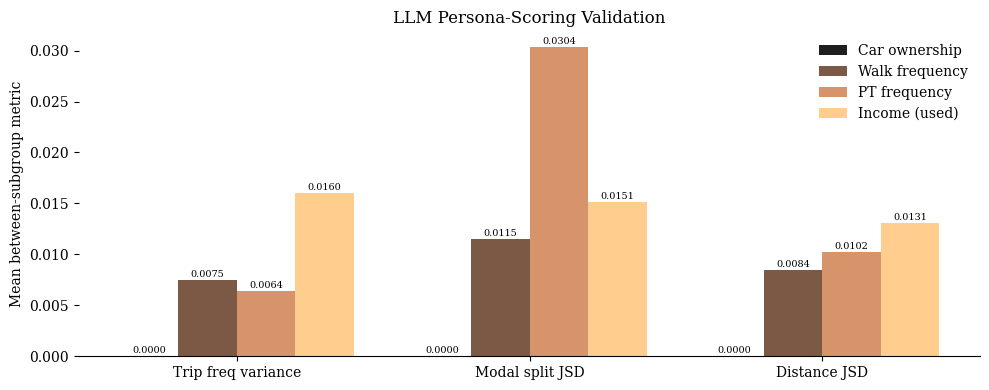

In [71]:
summary, details = validate_llm_persona_scoring(odin_train, scores, dim_col, used_label='Income', used_col='income_level_split')


In [72]:
## Colapsing the the car ownwership so the comparison is more truthful

car_collapse = {
    '0': '0 cars',
    '1': '1 car',
    '2': '2+ cars',
    '3': '2+ cars',
    '4': '2+ cars',
    '5': '2+ cars',
    '6': '2+ cars',
    '7': '2+ cars',
    '8': '2+ cars',
    '9 passenger cars or more': '2+ cars',
    'Unknown': np.nan,   # dropped by _attempt_split's notna() filter, same as any other NaN
}

odin_train['car_ownership_split'] = (
    odin_train['Number of passenger cars in household'].astype(str).replace(car_collapse)
)
dim_col['Car ownership'] = 'car_ownership_split'

print(odin_train['car_ownership_split'].value_counts(normalize=True, dropna=False).mul(100).round(1).sort_values())



car_ownership_split
NaN         0.3
0 cars     13.0
2+ cars    37.7
1 car      49.1
Name: proportion, dtype: float64


LLM Persona-Scoring Validation
(higher = more travel-behaviour differentiation between personas)
Split variable  LLM score Base groups split  Trip freq variance  Modal split JSD  Distance JSD
 Car ownership        7.9           35 / 82             0.02045          0.05798       0.02610
Walk frequency        7.8           11 / 82             0.00752          0.01153       0.00843
  PT frequency        7.7           17 / 82             0.00637          0.03037       0.01022
 Income (used)        6.1           27 / 82             0.01603          0.01513       0.01307

Interpretation:
  [Trip freq variance] Income (used) ranks 2/4 (0.01603). Outperformed by: Car ownership (0.02045).
           Income (used) beats: PT frequency (0.00637).
  [Modal split JSD] Income (used) ranks 3/4 (0.01513). Outperformed by: Car ownership (0.05798), PT frequency (0.03037).
  [Distance JSD] Income (used) ranks 2/4 (0.01307). Outperformed by: Car ownership (0.02610).
           Income (used) beats: Walk fre

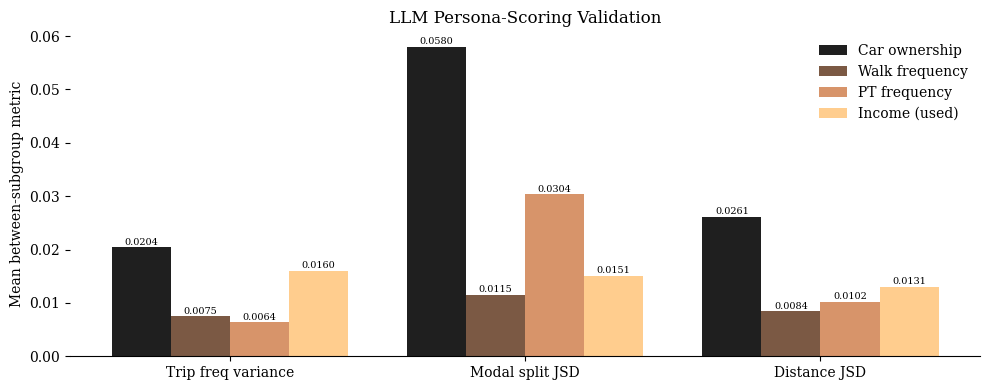

In [73]:
summary, details = validate_llm_persona_scoring(
    odin_train, scores, dim_col,
    used_label='Income', used_col='income_level_split',
    save_path=FIGURES_DIR / 'scoring_validation_income.png'
)